# Распространение волн

### Предварительные сведения

Задача основана на численном расчете (интегрировании) дифференциальных уравнений распространения волн 
в неоднородной двумерной среде. Теоретическая часть и прототип алгоритма расчета рассмотрены на семинарах.


### Дано

Прямоугольная область с соотношением сторон 3:2 (разрешение не менее 900х600). 
Изображение области и размещенных в ней объектов находится в файле: `var_i.png`, где `i` - номер варианта.
В этой области размещены объекты (в зависимости от варианта): линзы, призмы, зеркала, экран. 
Источником света (колебаний) в зависимости от варианта является направленный (варианты 1-5) или 
всенаправленный (точечный, варианты 6-7) источник.

**Замечание**

1. Допускаются небольшие передвижения и вращения объектов, качественно не изменяющие конфигурацию объектов.
2. Ход луча изображен условно и может не совпадать с расчетом. Основной критерий корректности пути луча:
луч должен пройти через все призмы/линзы, отразиться от зеркал, после чего достигнуть экрана.  


**Граничные условия:**

- открытая граница (`open boundary`) - по краям области
- условия Дирихле - на зеркалах

**Константы задачи:**

- пространственный шаг решетки `h = 1.0` 
- скорость распространения волн `c = 1.0`
- временной шаг `dt = h / (c * 1.5)`
- константа численной схемы (для среды вне объектов) `kappa = c * dt / h`
- замедление красной, зеленой и синей волн внутри объектов:
  - `kappa / kappa_r = 1.30`
  - `kappa / kappa_g = 1.35`  
  - `kappa / kappa_b = 1.40`  


**Требуется для варианта 7:**

Рассчитать амплитуду колебаний в двух точках комнаты Пенроуза: первая расположена в освещенной области и
максимально удалена от источника света, вторая - в неосвещенной области.
Подробности здесь: https://en.wikipedia.org/wiki/Illumination_problem


**Пример изображения области для варианта 0**

<img src='var_0.png' width=600></img>


### Требуется

Написать алгоритм расчета распространения волн с использованием библиотеки `Taichi` <0>, а также:

**Варианты 0-5**
  - подобрать необходимое количество итераций для получения дисперсионной картины <1>
  - построить график дисперсионной картины на экране <1>
  - записать анимацию распространения красной, зеленой и синей волны <1>
  - записать анимацию накопительного кадра <1>

**Вариант 6**
  - подобрать необходимое количество итераций для получения дисперсионной картины <1> 
  - построить график дисперсионной картины на экране <1>
  - записать анимацию распространения красной, зеленой и синей волны <2>
  - записать анимацию накопительного кадра <2>

**Вариант 7**
  - выполнить симуляцию для трех случаев, изображенных по ссылке к задаче <1> (за каждый не реализованный случай)
  - подобрать необходимое количество итераций для получения возмущения в первой точке и увеличить их в 2 раза <1>
  - построить графики амплитуды от времени для каждой из двух точек <1> 
  - записать анимацию распространения волны <2>
  - записать анимацию накопительного кадра <2>


### Оценивание

Тип штрафа указан в косых скобках к каждому требованию.

Итог = 100 - сумма_штрафов

**Штрафы**

- <0> - 50 баллов
- <1> - 20 баллов
- <2> - 30 баллов


### Материалы

- [Wave equation](https://en.wikipedia.org/wiki/Wave_equation)
- [The 2D wave equation - Solution with the method of finite differences in Python](https://beltoforion.de/en/recreational_mathematics/2d-wave-equation.php)
- [Wave on a string (interactive demo)](https://phet.colorado.edu/en/simulations/wave-on-a-string/teaching-resources)
- [Finite difference methods for 2D and 3D wave equations](https://hplgit.github.io/fdm-book/doc/pub/book/sphinx/._book008.html)
- [Absorbing Boundary Conditions for the Finite-Difference Approximation of the Time-Domain Electromagnetic-Field Equations GERRIT MUR](http://home.cc.umanitoba.ca/~lovetrij/cECE4390/Notes/Mur,%20G.%20-%20Absorbing%20BCs%20for%20the%20Finite-Difference%20Approximation%20of%20the%20TD%20EM%20Eqs.%20-%201981pdf.pdf)
- [Дисперсия света](https://ru.wikipedia.org/wiki/Дисперсия_света)
- [Показатель преломления](https://ru.wikipedia.org/wiki/Показатель_преломления)
- [Impulse function | Graphtoy](https://graphtoy.com/?f1(x,t)=exp(-(x%5E2)/2.0/2%5E2)/2&v1=true&f2(x,t)=&v2=false&f3(x,t)=&v3=false&f4(x,t)=cos(20*x)*f1(x,t)&v4=true&f5(x,t)=&v5=false&f6(x,t)=&v6=false&grid=1&coords=0,0,4.205926793776742)
- [Light-Simulation-WebGL](https://github.com/ArtemOnigiri/Light-Simulation-WebGL)
- [Симуляция волн света на клеточных автоматах](https://www.youtube.com/watch?v=noUpBKY2rIg)
- [Finite difference methods for wave equations](https://hplgit.github.io/fdm-book/doc/pub/wave/pdf/wave-4print.pdf)


## Решение. Вариант 5. Печенин Данила БПМ233.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from tqdm.auto import trange

from solver import init_taichi, WaveSolver, WIDTH, HEIGHT

arch = init_taichi()
print('Taichi backend:', arch)

[Taichi] Starting on arch=metal
Taichi backend: Arch.metal


In [12]:
# Константы задачи
h = 1.0
c = 1.0
dt = h / (c * 1.5)
base_kappa = c * dt / h
n = (1.30, 1.35, 1.40)
nx, ny = 900, 600

solver = WaveSolver(nx=nx, ny=ny, base_kappa=base_kappa, n=n, acc=0.15)
solver.build_geometry()
solver.init_impulse(xs=8.0, ys=35.0, angle=np.radians(0.0), freq=2.0, sigma_s=4.0, sigma_p=6.0)

tmask = solver.tmask.to_numpy()
mirror_mask = solver.mirror.to_numpy()
screen_x = 80.0
screen_col = int(screen_x / WIDTH * nx)

In [13]:
extent = [0, WIDTH, 0, HEIGHT]
glass_rgb = np.array([0.79, 0.89, 0.92])


def draw_objects(ax):
    """Рисует контур линзы, зеркало и экран поверх кадра."""
    xs = np.linspace(0, WIDTH, nx)
    ys = np.linspace(0, HEIGHT, ny)
    ax.contour(xs, ys, tmask, levels=[0.5], colors='white', linewidths=1.0)
    ax.plot([40, 60], [45, 45], color='cyan', lw=3)
    ax.text(50, 46.5, 'зеркало', color='cyan', ha='center')
    ax.plot([screen_x, screen_x], [10, 55], color='yellow', lw=3)
    ax.text(screen_x + 1, 33, 'экран', color='yellow', rotation=90, va='center')
    ax.text(15, 41, 'линза', color='white', ha='center')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_xticks(range(0, 91, 10))
    ax.set_yticks(range(0, 61, 10))


def wave_rgb(u_now, scale):
    """Поле u_now (3, ny, nx) -> цветная картинка (ny, nx, 3) для imshow.
    Яркость каждого канала = модуль амплитуды цвета, деленный на scale."""
    a = np.abs(u_now)
    rgb = (np.clip(a / scale, 0.0, 1.0) ** 0.6).transpose(1, 2, 0)
    g = tmask[..., None]
    rgb = rgb * (1 - 0.25 * g) + glass_rgb[None, None, :] * 0.25 * g
    return np.clip(rgb, 0, 1)


def accum_rgb(ac, scale):
    """Накопитель ac (3, ny, nx) -> цветная картинка (ny, nx, 3) для imshow."""
    rgb = (np.clip(ac / scale, 0.0, 1.0).transpose(1, 2, 0)) ** 0.5
    g = tmask[..., None]
    rgb = rgb * (1 - 0.2 * g) + glass_rgb[None, None, :] * 0.2 * g
    return np.clip(rgb, 0, 1)


def make_anim(frames, title, fname, fps=20):
    """Собирает анимацию из готовых кадров и сохраняет в mp4."""
    fig, ax = plt.subplots(figsize=(11, 7.3))
    im = ax.imshow(frames[0], origin='lower', extent=extent, animated=True)
    draw_objects(ax)
    ax.set_title(title)

    def update(i):
        im.set_data(frames[i])
        return [im]

    ani = FuncAnimation(fig, update, frames=len(frames), interval=1000 / fps, blit=True)
    ani.save(fname, writer='ffmpeg', fps=fps, dpi=110)
    plt.close(fig)
    return ani

Проверим первый кадр, а именно что у нас все правилььно по геометрии и волна начинает нормально распостроняться.

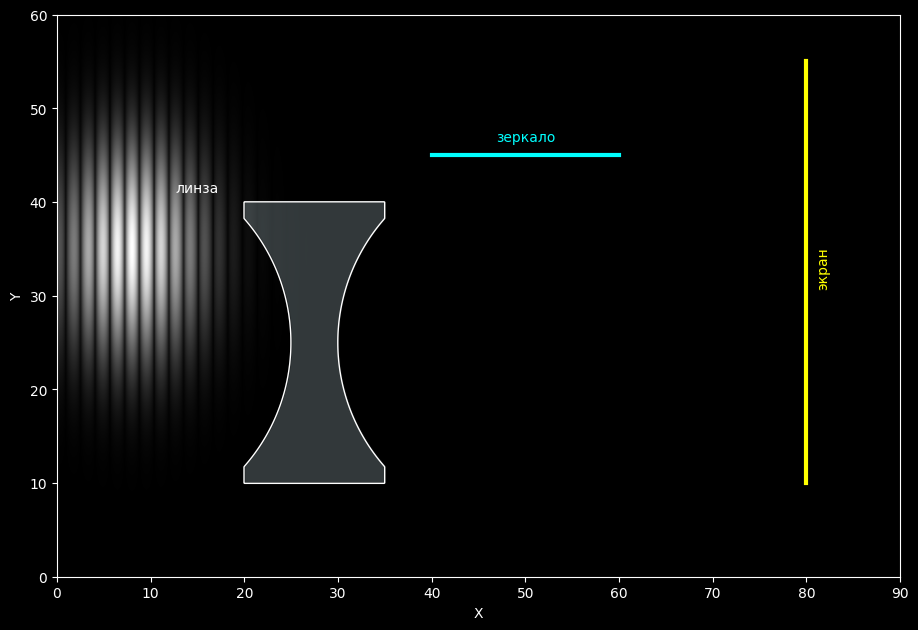

In [14]:
fig, ax = plt.subplots(figsize=(11, 7.3))
u0 = solver.u.to_numpy()[:, 1]
ax.imshow(wave_rgb(u0, np.abs(u0).max() + 1e-9), origin='lower', extent=extent)
draw_objects(ax)
plt.show()

Получилось все как надо.

Дисперсионную картину снимаем с накопителя на экране, поэтому важно не просто чтобы фронт долетел, а чтобы весь пакет прошел экран и профиль перестал меняться. Подбираем число итераций автоматически:

- каждые CHECK шагов берем профиль накопителя на экране и нормируем его на максимум
- как только профиль между двумя проверками меняется меньше чем на EPS, считаем картину установившейся и останавливаемся

In [15]:
REFRESH = 25 # сохранять кадр каждые REFRESH шагов
DS = 2 # прореживание кадров для видео
CHECK = 200 # как часто проверять сходимость профиля на экране
EPS = 2e-3 # порог сходимости нормированного профиля
MIN_IT = 1500 # не останавливаемся раньше, чем фронт дойдет до экрана (рассчитано эмперическим способом)
MAX_IT = 8000 # ограничиваем максимальное кол-во итераций на всякий случай

src = dict(xs=8.0, ys=35.0, angle=np.radians(0.0), freq=2.0, sigma_s=4.0, sigma_p=6.0)


def screen_profile():
    p = solver.accum.to_numpy()[:, :, screen_col - 3:screen_col + 3].mean(axis=2)
    return p / (p.max() + 1e-9)


# Проход 1: подбор IT по сходимости профиля + масштабы для нормировки видео.
solver.reset_fields()
solver.init_impulse(**src)
wave_scale = 0.0
prev = None
IT = MAX_IT
for k in trange(MAX_IT, desc='проход 1 (подбор IT)'):
    solver.step()
    if k % REFRESH == 0:
        m = float(np.abs(solver.u.to_numpy()[:, 1]).max())
        if m > wave_scale:
            wave_scale = m
    if k % CHECK == 0 and k >= MIN_IT:
        prof = screen_profile()
        if prev is not None and np.abs(prof - prev).max() < EPS:
            IT = k + 1
            break
        prev = prof
print('подобранное число итераций IT =', IT)
final_accum = solver.accum.to_numpy()
accum_scale = final_accum.max() + 1e-9
wave_scale = wave_scale + 1e-9

# Проход 2: повторяем ровно IT шагов и сохраняем кадры для анимаций.
solver.reset_fields()
solver.init_impulse(**src)
wave_imgs, accum_imgs = [], []
for k in trange(IT, desc='проход 2 (кадры)'):
    solver.step()
    if k % REFRESH == 0:
        u_now = solver.u.to_numpy()[:, 1]
        ac = solver.accum.to_numpy()
        wave_imgs.append((wave_rgb(u_now, wave_scale)[::DS, ::DS] * 255).astype(np.uint8))
        accum_imgs.append((accum_rgb(ac, accum_scale)[::DS, ::DS] * 255).astype(np.uint8))

проход 1 (подбор IT):  60%|██████    | 4800/8000 [00:04<00:03, 1055.41it/s]


подобранное число итераций IT = 4801


проход 2 (кадры): 100%|██████████| 4801/4801 [00:07<00:00, 627.28it/s]


In [18]:
ani_wave = make_anim(wave_imgs, 'Распространение волн R, G, B (вариант 5, Печенин Данила Михайлович, БПМ233)', 'rgb_propagation.mp4')

In [19]:
ani_accum = make_anim(accum_imgs, 'Накопительный кадр (вариант 5, Печенин Данила Михайлович, БПМ233)', 'accumulator.mp4')

Так теперь посмотрим на дисперсионную картину на экране.

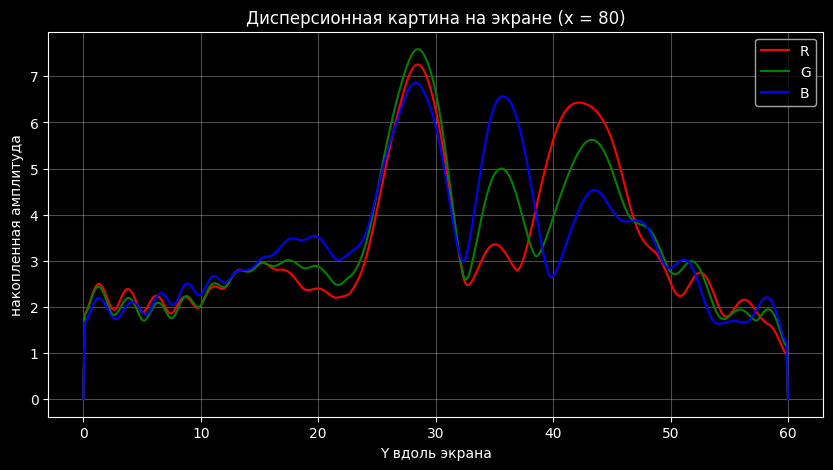

In [20]:
Y = np.linspace(0, HEIGHT, ny)
fig, ax = plt.subplots(figsize=(10, 5))
for cidx, name, col in [(0, 'R', 'red'), (1, 'G', 'green'), (2, 'B', 'blue')]:
    prof = final_accum[cidx, :, screen_col - 3:screen_col + 3].mean(axis=1)
    ax.plot(Y, prof, color=col, label=name)
ax.set_xlabel('Y вдоль экрана')
ax.set_ylabel('накопленная амплитуда')
ax.set_title('Дисперсионная картина на экране (x = 80)')
ax.legend()
ax.grid(alpha=0.3)
fig.savefig('dispersion.png', dpi=120, bbox_inches='tight')
plt.show()